<a href="https://colab.research.google.com/github/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes/blob/dataset-3-experiments/notebooks/experiments/brfss_eda_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CDC BRFSS Experiments 1-4

This notebook contains the CDC BRFSS experiments for the Type 2 Diabetes Prediction project.

## Experiments Included

### Experiment 1: Baseline Algorithm Comparison
Train Logistic Regression, LightGBM, and XGBoost on the raw, unbalanced CDC BRFSS dataset.

### Experiment 2: Class Imbalance Handling
Compare three strategies:
- No resampling
- SMOTE
- Class weighting

The main focus is to determine which strategy improves Recall and F1-score.

### Experiment 3: Feature Importance Analysis
Tune LightGBM and XGBoost, then extract feature importance rankings.

Since CDC BRFSS does not contain HbA1c or Glucose, this experiment focuses on health, lifestyle, demographic, and healthcare-access indicators such as BMI, general health, blood pressure, cholesterol, age, physical activity, and income.

### Experiment 4: Cross-Dataset Generalization
Train on one dataset and test on the other two without retraining.

For this experiment, only the common shared features are used:
- age
- bmi

This checks whether models transfer across different populations and helps identify possible feature drift.

## Notes
- Large CSV files were converted to Parquet to reduce file size.
- Logistic Regression uses scaled features.
- LightGBM and XGBoost use unscaled tabular features.
- SMOTE is applied only to training data where required.

In [1]:
#1 Imports
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

print("imports successfully loaded")

imports successfully loaded


In [2]:
#2 clone repo / move into project folder
if not os.path.exists("/content/Predicting-Type-2-Diabetes"):
    !git clone https://github.com/COMP3608-Intelligent-Systems-Project/Predicting-Type-2-Diabetes.git

%cd /content/Predicting-Type-2-Diabetes

Cloning into 'Predicting-Type-2-Diabetes'...
remote: Enumerating objects: 879, done.
remote: Counting objects: 100% (319/319), done.
remote: Compressing objects: 100% (252/252), done.
remote: Total 879 (delta 187), reused 79 (delta 67), pack-reused 560 (from 3)
Receiving objects: 100% (879/879), 28.03 MiB | 12.31 MiB/s, done.
Resolving deltas: 100% (443/443), done.
/content/Predicting-Type-2-Diabetes


In [3]:
#3 Install dependencies
!pip install pyarrow lightgbm xgboost imbalanced-learn -q

print("dependencies ready")

dependencies ready


In [4]:
#4 Load CDC BRFSS data using Parquet

raw_dir = "data/raw"
csv_path = f"{raw_dir}/diabetes_binary_health_indicators_BRFSS2015.csv"
parquet_path = f"{raw_dir}/diabetes_binary_health_indicators_BRFSS2015.parquet"

if os.path.exists(parquet_path):
    df = pd.read_parquet(parquet_path)
    print("Loaded CDC data from Parquet.")

elif os.path.exists(csv_path):
    print("Parquet file not found, but CSV exists. Converting CSV to Parquet...")
    df = pd.read_csv(csv_path)
    df.to_parquet(parquet_path, index=False, compression="zstd")
    print("Converted and loaded CDC data from CSV.")

else:
    raise FileNotFoundError(
        "CDC dataset not found. Add diabetes_binary_health_indicators_BRFSS2015.parquet to data/raw/."
    )

print("Shape:", df.shape)
display(df.head())

Parquet file not found, but CSV exists. Converting CSV to Parquet...
Converted and loaded CDC data from CSV.
Shape: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
#5 Prepare split used across all experiments

X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# scale only for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE data for Experiment 2 and 3
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
X_train_scaled_smote, y_train_scaled_smote = smote.fit_resample(X_train_scaled, y_train)

# XGBoost class-weighting value
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

print("-" * 50)
print(" CDC BRFSS Data Ready")
print("-" * 50)
print("Original shape:", df.shape)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nOriginal target balance (%):")
print((y.value_counts(normalize=True) * 100).round(2))
print("\nSMOTE training balance:")
print(pd.Series(y_train_smote).value_counts())
print(f"\nXGBoost scale_pos_weight: {scale_pos_weight:.2f}")

--------------------------------------------------
 CDC BRFSS Data Ready
--------------------------------------------------
Original shape: (253680, 22)
Train shape: (202944, 21)
Test shape: (50736, 21)

Original target balance (%):
Diabetes_binary
0.0    86.07
1.0    13.93
Name: proportion, dtype: float64

SMOTE training balance:
Diabetes_binary
0.0    174667
1.0    174667
Name: count, dtype: int64

XGBoost scale_pos_weight: 6.18


In [6]:
#6 Helper functions

def evaluate_predictions(strategy, model_name, y_true, y_pred, y_prob):
    return {
        "Experiment": strategy,
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_true, y_prob)
    }


def evaluate_model(strategy, model_name, model, X_eval, y_true):
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]

    metrics = evaluate_predictions(strategy, model_name, y_true, y_pred, y_prob)

    return metrics, y_pred, y_prob


def show_results_table(results, title):
    df_results = pd.DataFrame(results)
    print("-" * 70)
    print(title)
    print("-" * 70)
    display(df_results.round(4))
    return df_results

print("helper functions ready")

helper functions ready


# Experiment 1 - Baseline Algorithm Comparison

Raw, unbalanced CDC data.


In [7]:
#7 Experiment 1: Train baseline models
print("-" * 50)
print(" Experiment 1: Training Raw Baseline Models")
print("-" * 50)

# Logistic Regression
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train_scaled, y_train)
print("  Logistic Regression — done")

# LightGBM
lgbm_baseline = LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1)
lgbm_baseline.fit(X_train, y_train)
print("  LightGBM            — done")

# XGBoost
xgb_baseline = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb_baseline.fit(X_train, y_train)
print("  XGBoost             — done")

print("\nAll Experiment 1 models trained.")

--------------------------------------------------
 Experiment 1: Training Raw Baseline Models
--------------------------------------------------
  Logistic Regression — done
  LightGBM            — done
  XGBoost             — done

All Experiment 1 models trained.


In [8]:
#8 Experiment 1: Evaluate baseline models
exp1_models = {
    "Logistic Regression": (lr_baseline, X_test_scaled),
    "LightGBM": (lgbm_baseline, X_test),
    "XGBoost": (xgb_baseline, X_test)
}

exp1_results = []
exp1_predictions = {}

for name, (model, X_eval) in exp1_models.items():
    metrics, y_pred, y_prob = evaluate_model("Experiment 1 - Raw Baseline", name, model, X_eval, y_test)
    exp1_results.append(metrics)
    exp1_predictions[name] = {"y_pred": y_pred, "y_prob": y_prob}

exp1_df = show_results_table(exp1_results, "Experiment 1 - CDC Raw Baseline Comparison")

----------------------------------------------------------------------
Experiment 1 - CDC Raw Baseline Comparison
----------------------------------------------------------------------


,Experiment,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
0,Experiment 1 - Raw Baseline,Logistic Regression,0.8621,0.5171,0.1583,0.2424,0.8192
1,Experiment 1 - Raw Baseline,LightGBM,0.8655,0.5591,0.1640,0.2536,0.8269
2,Experiment 1 - Raw Baseline,XGBoost,0.8634,0.5309,0.1665,0.2535,0.8237


### Observation - Experiment 1 Baseline Metrics

The baseline models were trained on the original imbalanced CDC BRFSS data. All three models achieved high accuracy at around **86%**, but their recall for the diabetic class was low at around **16%**.

This shows that accuracy is misleading for this dataset because the majority of records are non-diabetic. The best baseline model by F1-score and AUC-ROC was **LightGBM**, but the overall F1-score was still low. This confirms that the raw imbalanced dataset makes it difficult for the models to correctly identify diabetic cases.

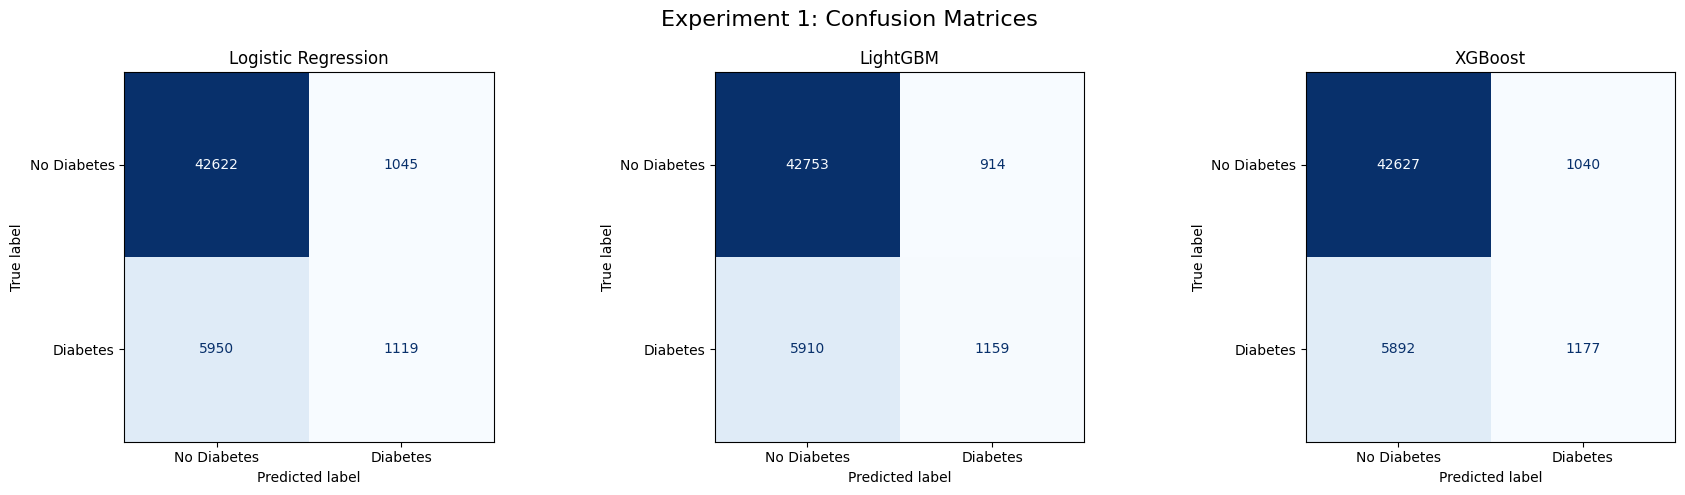

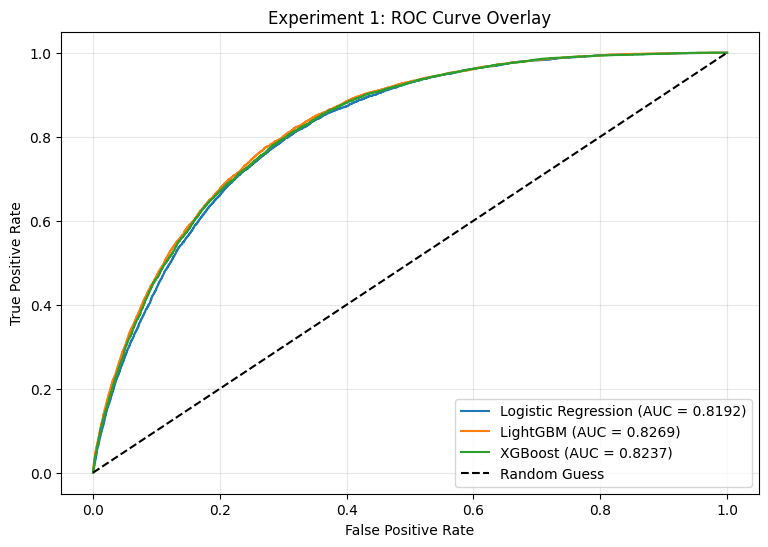

In [9]:
#9 Experiment 1: Confusion Matrices and ROC Curve
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, preds) in enumerate(exp1_predictions.items()):
    cm = confusion_matrix(y_test, preds["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Diabetes", "Diabetes"])
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False)
    axes[i].set_title(name)

plt.suptitle("Experiment 1: Confusion Matrices", fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))

for name, preds in exp1_predictions.items():
    fpr, tpr, _ = roc_curve(y_test, preds["y_prob"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Experiment 1: ROC Curve Overlay")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Observation - Experiment 1 Confusion Matrices and ROC Curves

The confusion matrices show that the baseline models correctly classify many non-diabetic cases, but miss many diabetic cases. This is expected because the dataset is heavily imbalanced toward the non-diabetic class.

The ROC curves show that the models can still separate the two classes reasonably well by probability score, but the default classification threshold does not catch many diabetic cases. This supports the need for imbalance-handling strategies in Experiment 2.

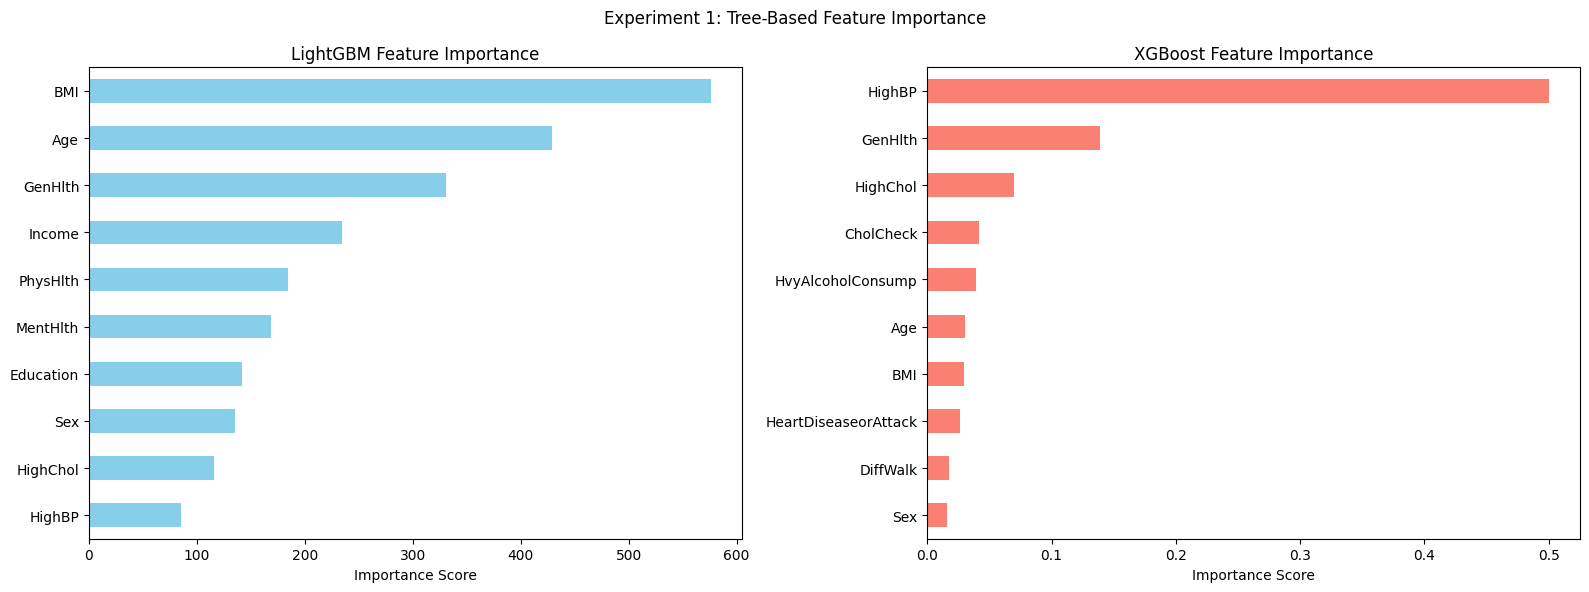

In [10]:
#10 Experiment 1: Tree feature importance only
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

lgbm_importances = pd.Series(lgbm_baseline.feature_importances_, index=X.columns).sort_values(ascending=True)
lgbm_importances.tail(10).plot(kind="barh", ax=axes[0], color="skyblue")
axes[0].set_title("LightGBM Feature Importance")
axes[0].set_xlabel("Importance Score")

xgb_importances = pd.Series(xgb_baseline.feature_importances_, index=X.columns).sort_values(ascending=True)
xgb_importances.tail(10).plot(kind="barh", ax=axes[1], color="salmon")
axes[1].set_title("XGBoost Feature Importance")
axes[1].set_xlabel("Importance Score")

plt.suptitle("Experiment 1: Tree-Based Feature Importance")
plt.tight_layout()
plt.show()

### Observation - Experiment 1 Feature Importance

The feature-importance plots show which variables the tree-based baseline models used most. Features such as **general health, BMI, age, high blood pressure, and high cholesterol** appear important.

Logistic Regression feature importance was not included here because Logistic Regression does not produce feature importance in the same way tree models do. For Logistic Regression, coefficients can be inspected separately, but this experiment focuses mainly on baseline performance.

In [11]:
#11 Experiment 1: Short finding
best_f1 = exp1_df.sort_values("F1 Score", ascending=False).iloc[0]
best_auc = exp1_df.sort_values("AUC-ROC", ascending=False).iloc[0]

print("Experiment 1 Finding")
print("-" * 35)
print(f"Best model by F1 Score: {best_f1['Model']} ({best_f1['F1 Score']:.4f})")
print(f"Best model by AUC-ROC : {best_auc['Model']} ({best_auc['AUC-ROC']:.4f})")
print("\nThis is the raw, imbalanced baseline used for comparison in Experiment 2.")

Experiment 1 Finding
-----------------------------------
Best model by F1 Score: LightGBM (0.2536)
Best model by AUC-ROC : LightGBM (0.8269)

This is the raw, imbalanced baseline used for comparison in Experiment 2.


# Experiment 2 - Class Imbalance Handling

Compare three strategies:

1. No resampling  
2. SMOTE  
3. Class weighting  

Main focus:
- Recall
- F1 Score


In [12]:
#12 Experiment 2: Train no resampling models

print("-" * 50)
print(" Experiment 2 Strategy 1: No Resampling")
print("-" * 50)

lr_raw = LogisticRegression(max_iter=1000, random_state=42)
lr_raw.fit(X_train_scaled, y_train)

lgbm_raw = LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1)
lgbm_raw.fit(X_train, y_train)

xgb_raw = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb_raw.fit(X_train, y_train)

print("No resampling models trained.")

--------------------------------------------------
 Experiment 2 Strategy 1: No Resampling
--------------------------------------------------
No resampling models trained.


In [13]:
#13 Experiment 2: Train SMOTE models
print("-" * 50)
print(" Experiment 2 Strategy 2: SMOTE")
print("-" * 50)

lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_scaled_smote, y_train_scaled_smote)

lgbm_smote = LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1)
lgbm_smote.fit(X_train_smote, y_train_smote)

xgb_smote = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
xgb_smote.fit(X_train_smote, y_train_smote)

print("SMOTE models trained.")

--------------------------------------------------
 Experiment 2 Strategy 2: SMOTE
--------------------------------------------------
SMOTE models trained.


In [14]:
#14 Experiment 2: Train class weighted models
print("-" * 50)
print(" Experiment 2 Strategy 3: Class Weighting")
print("-" * 50)

lr_weighted = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr_weighted.fit(X_train_scaled, y_train)

lgbm_weighted = LGBMClassifier(
    n_estimators=100,
    random_state=42,
    verbosity=-1,
    class_weight="balanced"
)
lgbm_weighted.fit(X_train, y_train)

xgb_weighted = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)
xgb_weighted.fit(X_train, y_train)

print("Class weighted models trained.")

--------------------------------------------------
 Experiment 2 Strategy 3: Class Weighting
--------------------------------------------------
Class weighted models trained.


In [15]:
#15 Experiment 2: Evaluate all imbalance strategies

exp2_models = {
    ("No Resampling", "Logistic Regression"): (lr_raw, X_test_scaled),
    ("No Resampling", "LightGBM"): (lgbm_raw, X_test),
    ("No Resampling", "XGBoost"): (xgb_raw, X_test),

    ("SMOTE", "Logistic Regression"): (lr_smote, X_test_scaled),
    ("SMOTE", "LightGBM"): (lgbm_smote, X_test),
    ("SMOTE", "XGBoost"): (xgb_smote, X_test),

    ("Class Weighting", "Logistic Regression"): (lr_weighted, X_test_scaled),
    ("Class Weighting", "LightGBM"): (lgbm_weighted, X_test),
    ("Class Weighting", "XGBoost"): (xgb_weighted, X_test),
}

exp2_results = []
exp2_predictions = {}

for (strategy, name), (model, X_eval) in exp2_models.items():
    metrics, y_pred, y_prob = evaluate_model(strategy, name, model, X_eval, y_test)
    exp2_results.append(metrics)
    exp2_predictions[(strategy, name)] = {"y_pred": y_pred, "y_prob": y_prob}

exp2_df = pd.DataFrame(exp2_results)

print("-" * 70)
print("Experiment 2 - CDC Imbalance Strategy Comparison")
print("-" * 70)
display(exp2_df.round(4).sort_values(by=["F1 Score", "Recall"], ascending=False))

----------------------------------------------------------------------
Experiment 2 - CDC Imbalance Strategy Comparison
----------------------------------------------------------------------


,Experiment,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
3,SMOTE,Logistic Regression,0.7331,0.3122,0.7614,0.4429,0.8188
8,Class Weighting,XGBoost,0.7284,0.3100,0.7745,0.4428,0.8218
6,Class Weighting,Logistic Regression,0.7315,0.3107,0.7611,0.4413,0.8196
7,Class Weighting,LightGBM,0.7203,0.3056,0.7915,0.4409,0.8267
4,SMOTE,LightGBM,0.8630,0.5212,0.2067,0.2960,0.8235
5,SMOTE,XGBoost,0.8640,0.5342,0.1856,0.2755,0.8231
1,No Resampling,LightGBM,0.8655,0.5591,0.1640,0.2536,0.8269
2,No Resampling,XGBoost,0.8634,0.5309,0.1665,0.2535,0.8237
0,No Resampling,Logistic Regression,0.8621,0.5171,0.1583,0.2424,0.8192


### Observation - Experiment 2 Imbalance Strategy Results

Experiment 2 shows a clear improvement in recall when imbalance-handling strategies are used. The best F1-score came from **SMOTE + Logistic Regression**, while the highest recall came from **Class Weighting + LightGBM**.

Compared with the raw baseline, SMOTE and class weighting helped the models detect more diabetic cases. However, this improvement in recall came with lower precision and lower accuracy, meaning the models made more false-positive predictions. In a medical screening context, this trade-off may be acceptable because missing diabetic cases is usually more serious than flagging extra possible cases.

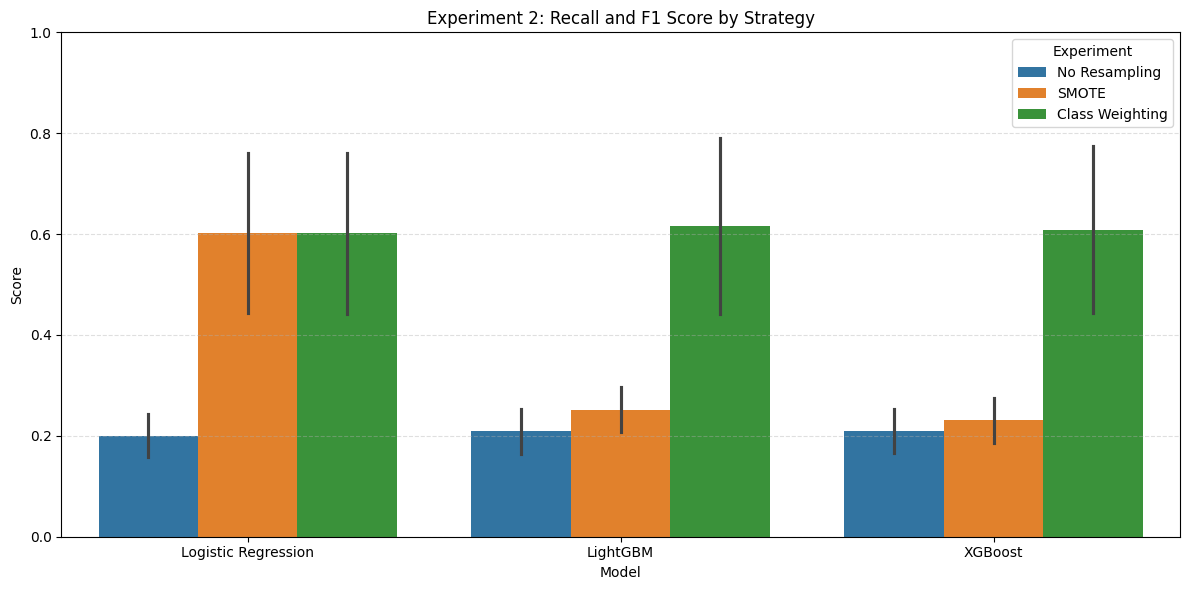

In [16]:
#16 Experiment 2: Recall and F1 comparison
plot_df = exp2_df.melt(
    id_vars=["Experiment", "Model"],
    value_vars=["Recall", "F1 Score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Experiment")
plt.title("Experiment 2: Recall and F1 Score by Strategy")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Observation - Experiment 2 Recall and F1 Plot

The Recall and F1-score plot makes the trade-off easier to see. The raw baseline models have low recall, while SMOTE and class weighting increase recall substantially.

The most important takeaway is that balancing strategies help the models become more sensitive to the diabetic class. This supports the purpose of Experiment 2, which is to test whether imbalance handling improves clinical safety by reducing missed diabetic cases.

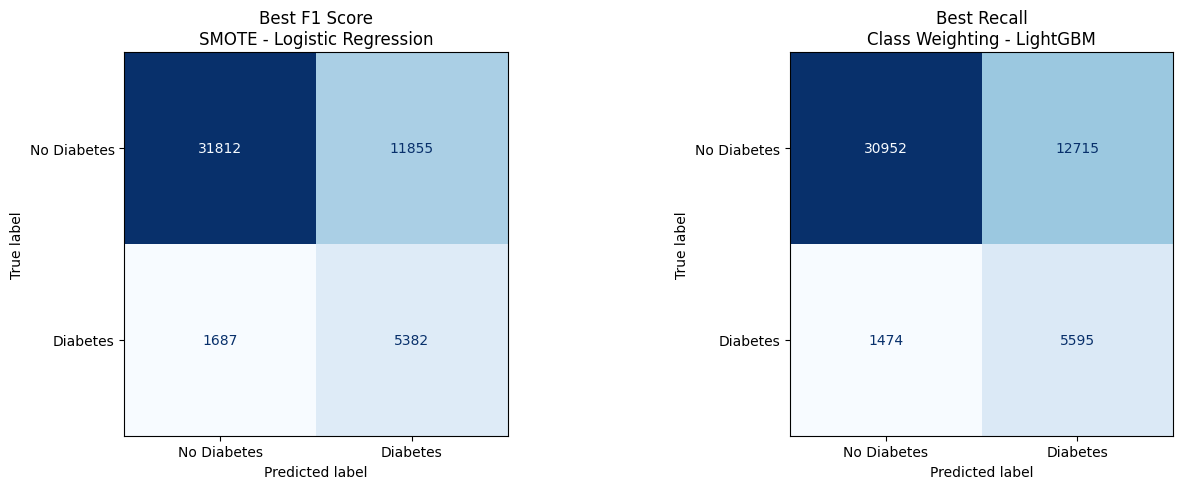

In [17]:
#17 Experiment 2: Confusion matrices for best F1 and best Recall
best_f1_row = exp2_df.sort_values("F1 Score", ascending=False).iloc[0]
best_recall_row = exp2_df.sort_values("Recall", ascending=False).iloc[0]

best_cases = [
    ("Best F1 Score", best_f1_row),
    ("Best Recall", best_recall_row)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (title, row) in enumerate(best_cases):
    key = (row["Experiment"], row["Model"])
    y_pred = exp2_predictions[key]["y_pred"]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Diabetes", "Diabetes"])
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False)
    axes[i].set_title(f"{title}\n{row['Experiment']} - {row['Model']}")

plt.tight_layout()
plt.show()

### Observation - Experiment 2 Best Model Confusion Matrices

The confusion matrices for the best F1 and best Recall models show the difference between a balanced model and a highly sensitive model. The best Recall model catches more diabetic cases, but it may also classify more non-diabetic cases as diabetic.

This confirms that recall and precision must be considered together. A high-recall model is useful for screening, while a higher-F1 model gives a better balance between detecting diabetes and avoiding too many false alarms.

In [18]:
#18 Experiment 2: Short Finding
best_f1 = exp2_df.sort_values("F1 Score", ascending=False).iloc[0]
best_recall = exp2_df.sort_values("Recall", ascending=False).iloc[0]

print("Experiment 2 Finding")
print("-" * 40)
print(f"Best by F1 Score: {best_f1['Experiment']} - {best_f1['Model']} ({best_f1['F1 Score']:.4f})")
print(f"Best by Recall  : {best_recall['Experiment']} - {best_recall['Model']} ({best_recall['Recall']:.4f})")
print("\nHigher recall means the model catches more diabetic cases.")
print("Higher F1 means a better balance between recall and precision.")

Experiment 2 Finding
----------------------------------------
Best by F1 Score: SMOTE - Logistic Regression (0.4429)
Best by Recall  : Class Weighting - LightGBM (0.7915)

Higher recall means the model catches more diabetic cases.
Higher F1 means a better balance between recall and precision.


# Experiment 3 - Feature Importance Analysis

Tune LightGBM and XGBoost, then compare feature importance.

For CDC BRFSS, there is no HbA1c or Glucose feature.  
So this dataset focuses on health, lifestyle, demographic, and healthcare access features.


In [19]:
#19 Experiment 3: Create tuning sample
tuning_sample_size = min(60000, len(X_train_smote))

X_tune, _, y_tune, _ = train_test_split(
    X_train_smote,
    y_train_smote,
    train_size=tuning_sample_size,
    random_state=42,
    stratify=y_train_smote
)

print("Tuning sample shape:", X_tune.shape)
print("Tuning target balance:")
print(pd.Series(y_tune).value_counts())

Tuning sample shape: (60000, 21)
Tuning target balance:
Diabetes_binary
1.0    30000
0.0    30000
Name: count, dtype: int64


In [20]:
#20 Experiment 3: Tune LightGBM
print("-" * 50)
print(" Experiment 3: Tuning LightGBM")
print("-" * 50)

lgbm_base = LGBMClassifier(random_state=42, verbosity=-1)

lgbm_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [-1, 5, 10]
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=lgbm_param_grid,
    n_iter=6,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lgbm_search.fit(X_tune, y_tune)

print("Best LightGBM parameters:")
print(lgbm_search.best_params_)
print("\nBest LightGBM CV F1 Score:")
print(round(lgbm_search.best_score_, 4))

--------------------------------------------------
 Experiment 3: Tuning LightGBM
--------------------------------------------------
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best LightGBM parameters:
{'num_leaves': 31, 'n_estimators': 200, 'max_depth': -1, 'learning_rate': 0.05}

Best LightGBM CV F1 Score:
0.9119


In [21]:
#21 Experiment 3: Train final tuned LightGBM
best_lgbm = LGBMClassifier(
    **lgbm_search.best_params_,
    random_state=42,
    verbosity=-1
)

best_lgbm.fit(X_train_smote, y_train_smote)

lgbm_tuned_metrics, lgbm_tuned_pred, lgbm_tuned_prob = evaluate_model(
    "Experiment 3 - Tuned",
    "Tuned LightGBM",
    best_lgbm,
    X_test,
    y_test
)

print("Tuned LightGBM evaluated.")
print(classification_report(y_test, lgbm_tuned_pred, zero_division=0))

Tuned LightGBM evaluated.
              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92     43667
         1.0       0.52      0.20      0.29      7069

    accuracy                           0.86     50736
   macro avg       0.70      0.59      0.61     50736
weighted avg       0.83      0.86      0.84     50736



In [22]:
#22 Experiment 3: Tune XGBoost
print("-" * 50)
print(" Experiment 3: Tuning XGBoost")
print("-" * 50)

xgb_base = XGBClassifier(random_state=42, eval_metric="logloss")

xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=6,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_tune, y_tune)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)
print("\nBest XGBoost CV F1 Score:")
print(round(xgb_search.best_score_, 4))

--------------------------------------------------
 Experiment 3: Tuning XGBoost
--------------------------------------------------
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best XGBoost parameters:
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Best XGBoost CV F1 Score:
0.9085


In [23]:
#23 Experiment 3: Train final tuned XGBoost
best_xgb = XGBClassifier(
    **xgb_search.best_params_,
    random_state=42,
    eval_metric="logloss"
)

best_xgb.fit(X_train_smote, y_train_smote)

xgb_tuned_metrics, xgb_tuned_pred, xgb_tuned_prob = evaluate_model(
    "Experiment 3 - Tuned",
    "Tuned XGBoost",
    best_xgb,
    X_test,
    y_test
)

print("Tuned XGBoost evaluated.")
print(classification_report(y_test, xgb_tuned_pred, zero_division=0))

Tuned XGBoost evaluated.
              precision    recall  f1-score   support

         0.0       0.89      0.96      0.92     43667
         1.0       0.52      0.23      0.32      7069

    accuracy                           0.86     50736
   macro avg       0.70      0.60      0.62     50736
weighted avg       0.83      0.86      0.84     50736



In [24]:
#24 Experiment 3: Tuned model comparison
exp3_df = pd.DataFrame([lgbm_tuned_metrics, xgb_tuned_metrics])

print("-" * 60)
print("Experiment 3 - Tuned Model Comparison")
print("-" * 60)
display(exp3_df.round(4))

------------------------------------------------------------
Experiment 3 - Tuned Model Comparison
------------------------------------------------------------


,Experiment,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
0,Experiment 3 - Tuned,Tuned LightGBM,0.8631,0.5226,0.2046,0.2940,0.8234
1,Experiment 3 - Tuned,Tuned XGBoost,0.8626,0.5151,0.2316,0.3195,0.8219


### Observation - Experiment 3 Tuned Model Performance

After tuning, **XGBoost** achieved the better F1-score between the two tuned tree models. LightGBM and XGBoost both maintained high overall accuracy, but recall remained relatively low compared with the best imbalance-handling models from Experiment 2.

This suggests that tuning alone does not fully solve the class imbalance issue. Hyperparameter tuning can improve model behavior, but imbalance handling is still important for detecting diabetic cases in the CDC BRFSS dataset.

In [25]:
#25 Experiment 3: Extract feature importance
lgbm_importance = pd.DataFrame({
    "Feature": X.columns,
    "LightGBM Importance": best_lgbm.feature_importances_
})

xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "XGBoost Importance": best_xgb.feature_importances_
})

lgbm_importance["LightGBM Normalized"] = (
    lgbm_importance["LightGBM Importance"] / lgbm_importance["LightGBM Importance"].sum()
)

xgb_importance["XGBoost Normalized"] = (
    xgb_importance["XGBoost Importance"] / xgb_importance["XGBoost Importance"].sum()
)

importance_df = pd.merge(lgbm_importance, xgb_importance, on="Feature")

importance_df["Average Importance"] = (
    importance_df["LightGBM Normalized"] +
    importance_df["XGBoost Normalized"]
) / 2

importance_df = importance_df.sort_values("Average Importance", ascending=False)

display(importance_df.head(10))

,Feature,LightGBM Importance,LightGBM Normalized,XGBoost Importance,XGBoost Normalized,Average Importance
13,GenHlth,892,0.148667,0.053071,0.053071,0.100869
0,HighBP,302,0.050333,0.150671,0.150671,0.100502
18,Age,977,0.162833,0.024872,0.024872,0.093853
3,BMI,779,0.129833,0.021156,0.021156,0.075495
8,Fruits,135,0.022500,0.105691,0.105691,0.064095
1,HighChol,295,0.049167,0.076421,0.076421,0.062794
17,Sex,303,0.050500,0.061269,0.061269,0.055884
4,Smoker,174,0.029000,0.074114,0.074114,0.051557
7,PhysActivity,116,0.019333,0.069994,0.069994,0.044664
10,HvyAlcoholConsump,145,0.024167,0.063692,0.063692,0.043929


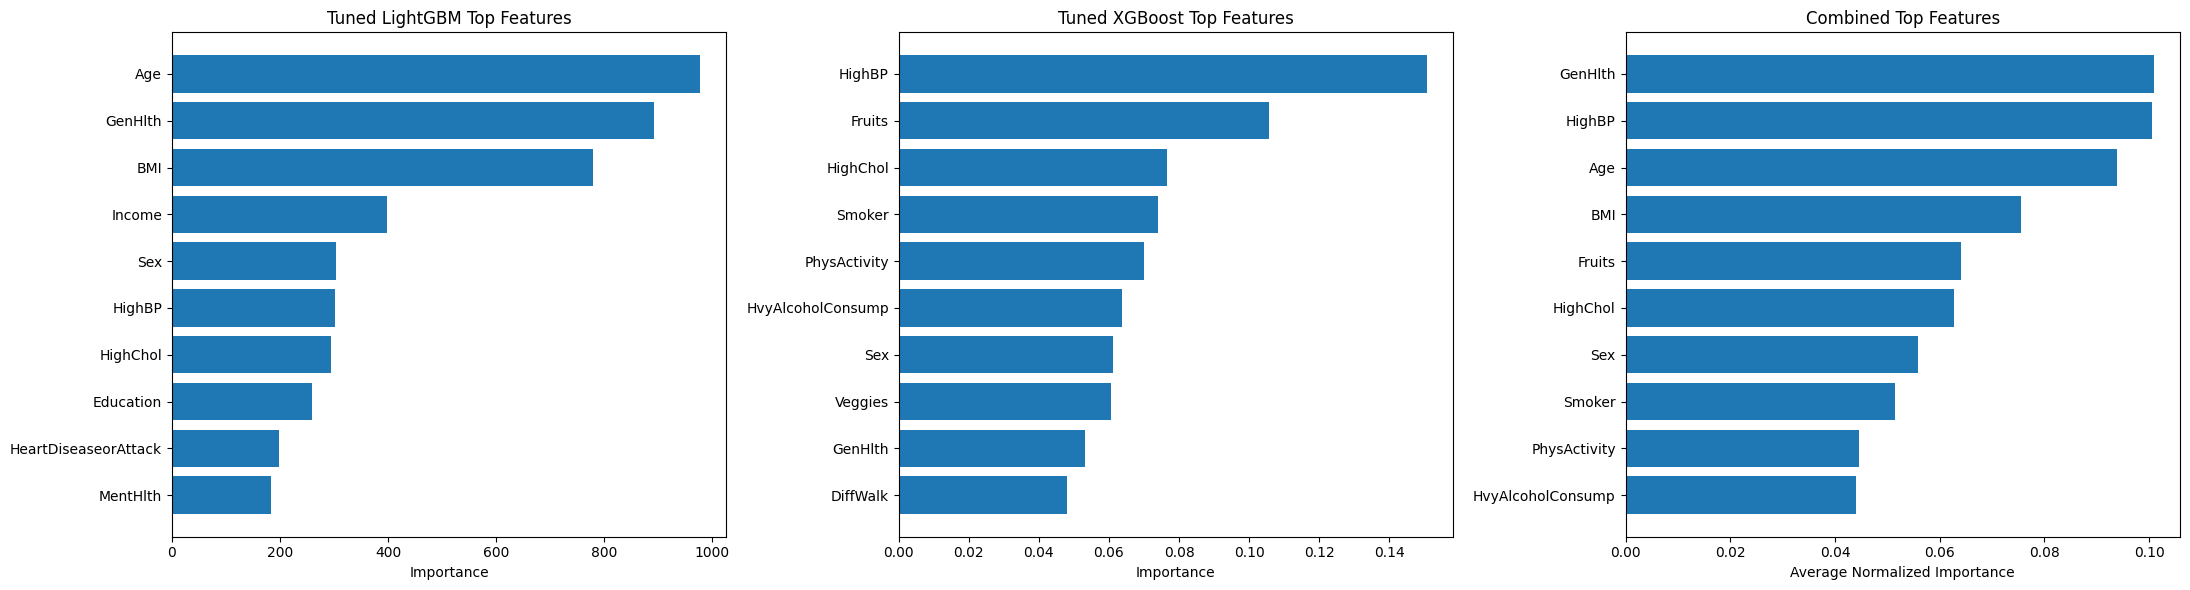

In [26]:
#26 Experiment 3: Plot feature importance
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

top_lgbm = lgbm_importance.sort_values("LightGBM Importance", ascending=True).tail(10)
axes[0].barh(top_lgbm["Feature"], top_lgbm["LightGBM Importance"])
axes[0].set_title("Tuned LightGBM Top Features")
axes[0].set_xlabel("Importance")

top_xgb = xgb_importance.sort_values("XGBoost Importance", ascending=True).tail(10)
axes[1].barh(top_xgb["Feature"], top_xgb["XGBoost Importance"])
axes[1].set_title("Tuned XGBoost Top Features")
axes[1].set_xlabel("Importance")

top_combined = importance_df.sort_values("Average Importance", ascending=True).tail(10)
axes[2].barh(top_combined["Feature"], top_combined["Average Importance"])
axes[2].set_title("Combined Top Features")
axes[2].set_xlabel("Average Normalized Importance")

plt.tight_layout()
plt.show()

### Observation - Experiment 3 Feature Importance Plots

The tuned LightGBM and XGBoost models ranked several health-related variables highly. Important features included **general health, high blood pressure, age, BMI, and high cholesterol**.

The CDC BRFSS dataset does not contain direct clinical lab measurements like HbA1c or blood glucose. Because of this, the feature-importance analysis is based on survey health indicators and lifestyle variables instead of laboratory biomarkers.

,Feature Group,Average Importance
0,Health Indicators,0.587853
1,Lifestyle,0.247554
2,Demographic / Socioeconomic,0.138192
3,Healthcare Access,0.026400


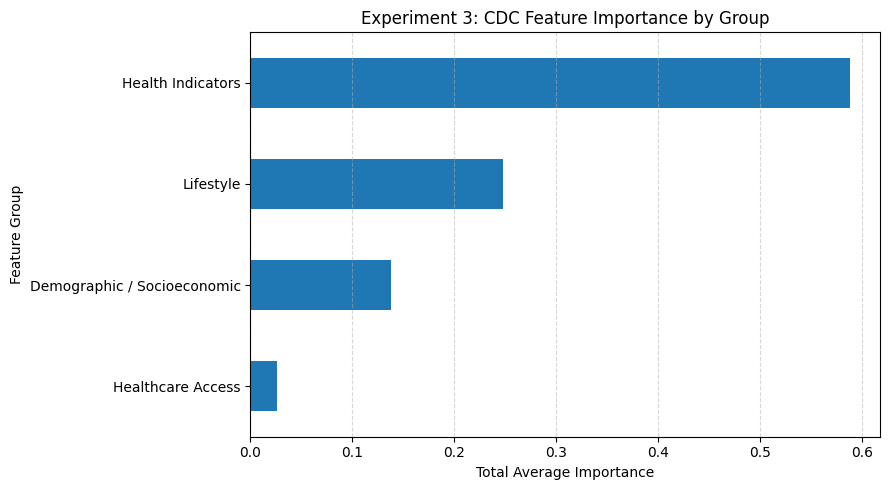

In [27]:
#27 Experiment 3: Group Feature Importance
feature_groups = {
    "Health Indicators": [
        "HighBP", "HighChol", "CholCheck", "BMI", "Stroke",
        "HeartDiseaseorAttack", "GenHlth", "MentHlth",
        "PhysHlth", "DiffWalk", "Age"
    ],
    "Lifestyle": [
        "Smoker", "PhysActivity", "Fruits", "Veggies",
        "HvyAlcoholConsump"
    ],
    "Healthcare Access": [
        "AnyHealthcare", "NoDocbcCost"
    ],
    "Demographic / Socioeconomic": [
        "Sex", "Education", "Income"
    ]
}

def assign_group(feature):
    for group, features in feature_groups.items():
        if feature in features:
            return group
    return "Other"

importance_df["Feature Group"] = importance_df["Feature"].apply(assign_group)

group_importance = (
    importance_df.groupby("Feature Group")["Average Importance"]
    .sum()
    .sort_values(ascending=False)
)

display(group_importance.reset_index())

plt.figure(figsize=(9, 5))
group_importance.sort_values(ascending=True).plot(kind="barh")
plt.title("Experiment 3: CDC Feature Importance by Group")
plt.xlabel("Total Average Importance")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Observation - Experiment 3 Feature Groups

The grouped feature-importance chart shows that **health indicators** contributed the most overall importance. Lifestyle features were also meaningful, while healthcare-access and demographic/socioeconomic features contributed less.

This suggests that the CDC BRFSS model mainly relies on self-reported health status and known risk indicators, rather than demographic information alone. This is useful because it supports the idea that survey-based health variables can still provide predictive value even without lab-based clinical features.

# Experiment 3B - Top-K Features vs All Features

This section compares model performance when using:

- all CDC BRFSS features
- only the top 5 features
- only the top 10 features

The top-k features are selected from the combined LightGBM and XGBoost feature-importance ranking from Experiment 3.

This is included to check whether a smaller group of important CDC survey features can capture most of the predictive signal.


In [28]:
#28 Experiment 3B: Compare top-k features against all features

topk_feature_sets = {
    "All Features": X.columns.tolist(),
    "Top 5 Features": importance_df.head(5)["Feature"].tolist(),
    "Top 10 Features": importance_df.head(10)["Feature"].tolist()
}

print("Feature sets used:")
for name, features in topk_feature_sets.items():
    print(f"{name}: {features}")


def evaluate_topk_model(model_name, model, feature_set_name, features):
    model.fit(X_train_smote[features], y_train_smote)

    y_pred = model.predict(X_test[features])
    y_prob = model.predict_proba(X_test[features])[:, 1]

    return {
        "Model": model_name,
        "Feature Set": feature_set_name,
        "Number of Features": len(features),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_test, y_prob)
    }


topk_results = []

model_builders = {
    "Tuned LightGBM": lambda: LGBMClassifier(
        **lgbm_search.best_params_,
        random_state=42,
        verbosity=-1
    ),
    "Tuned XGBoost": lambda: XGBClassifier(
        **xgb_search.best_params_,
        random_state=42,
        eval_metric="logloss"
    )
}

for model_name, build_model in model_builders.items():
    for feature_set_name, features in topk_feature_sets.items():
        result = evaluate_topk_model(
            model_name,
            build_model(),
            feature_set_name,
            features
        )
        topk_results.append(result)

topk_df = pd.DataFrame(topk_results)

print("-" * 70)
print("Experiment 3B - Top-K Features vs All Features")
print("-" * 70)

display(
    topk_df
    .sort_values(by=["Model", "Number of Features"])
    .round(4)
)


Feature sets used:
All Features: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
Top 5 Features: ['GenHlth', 'HighBP', 'Age', 'BMI', 'Fruits']
Top 10 Features: ['GenHlth', 'HighBP', 'Age', 'BMI', 'Fruits', 'HighChol', 'Sex', 'Smoker', 'PhysActivity', 'HvyAlcoholConsump']
----------------------------------------------------------------------
Experiment 3B - Top-K Features vs All Features
----------------------------------------------------------------------


,Model,Feature Set,Number of Features,Accuracy,Precision,Recall,F1 Score,AUC-ROC
1,Tuned LightGBM,Top 5 Features,5,0.8485,0.4408,0.3251,0.3742,0.8078
2,Tuned LightGBM,Top 10 Features,10,0.8597,0.4929,0.2521,0.3336,0.8185
0,Tuned LightGBM,All Features,21,0.8631,0.5226,0.2046,0.2940,0.8234
4,Tuned XGBoost,Top 5 Features,5,0.8381,0.4149,0.3957,0.4051,0.8080
5,Tuned XGBoost,Top 10 Features,10,0.8566,0.4751,0.2807,0.3529,0.8177
3,Tuned XGBoost,All Features,21,0.8626,0.5151,0.2316,0.3195,0.8219


### Observation - Top-K Features vs All Features

This comparison shows how much performance is retained when the models use only the highest-ranked CDC BRFSS features instead of the full feature set.

For this CDC dataset, the top features are survey-based health indicators rather than direct clinical lab values. If the top 5 or top 10 feature results are close to the all-feature results, it suggests that a small number of health indicators captures most of the useful signal. If performance drops, it means the weaker features still add useful information to the model.

This is important because a smaller feature set can make a model simpler and easier to interpret, but the trade-off is that it may lose some predictive performance.


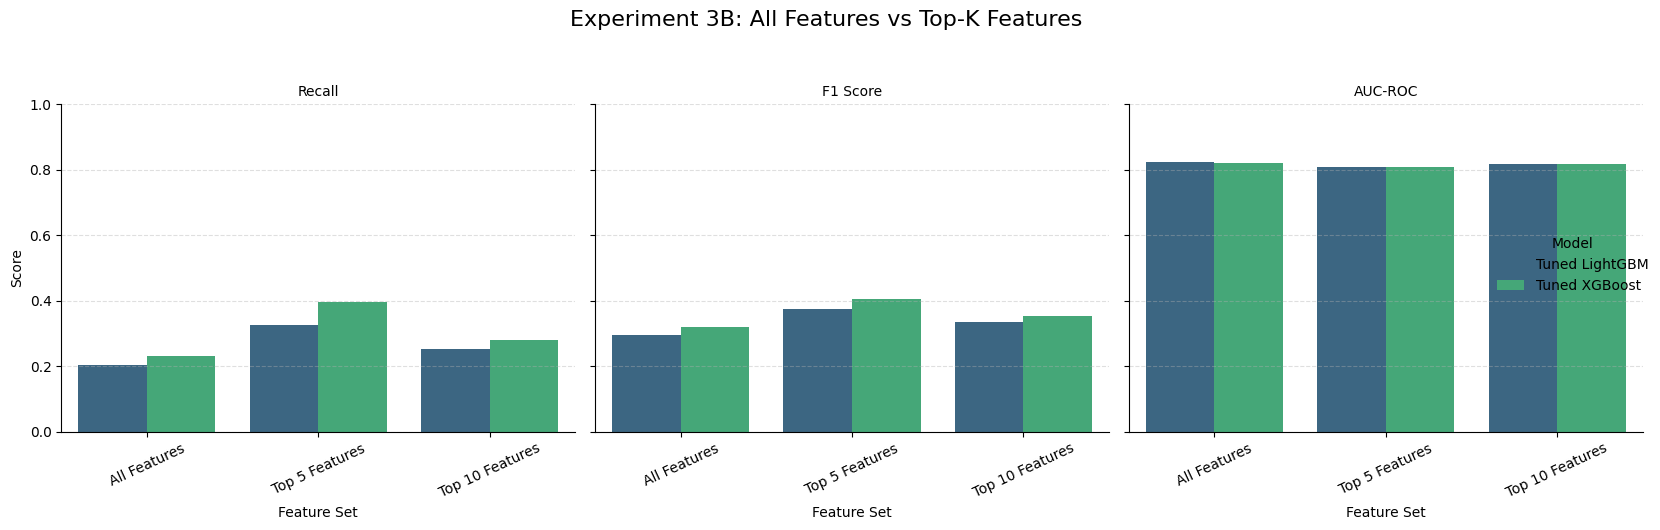

In [29]:
#29 Experiment 3B: Visualize top-k comparison

topk_plot_df = topk_df.melt(
    id_vars=["Model", "Feature Set", "Number of Features"],
    value_vars=["Recall", "F1 Score", "AUC-ROC"],
    var_name="Metric",
    value_name="Score"
)

g = sns.catplot(
    data=topk_plot_df,
    kind="bar",
    x="Feature Set",
    y="Score",
    hue="Model",
    col="Metric",
    height=5,
    aspect=1,
    palette="viridis"
)

g.set_titles("{col_name}")
g.set_axis_labels("Feature Set", "Score")

for ax in g.axes.flat:
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Experiment 3B: All Features vs Top-K Features", y=1.05, fontsize=16)
plt.tight_layout()
plt.show()


### Observation - Top-K Feature Plot

The plot makes it easier to compare how Recall, F1-score, and AUC-ROC change as the feature set is reduced.

The goal is not necessarily for top-k features to outperform all features. Instead, the goal is to see whether the model can remain reasonably effective using fewer, more interpretable predictors. For CDC BRFSS, this helps show whether survey-based health indicators such as general health, BMI, blood pressure, cholesterol, and age are carrying most of the prediction signal.


In [30]:
#30 Experiment 3B: Short finding

best_all_features = (
    topk_df[topk_df["Feature Set"] == "All Features"]
    .sort_values("F1 Score", ascending=False)
    .iloc[0]
)

best_topk_features = (
    topk_df[topk_df["Feature Set"] != "All Features"]
    .sort_values("F1 Score", ascending=False)
    .iloc[0]
)

print("Experiment 3B Finding")
print("-" * 45)

print("Best all-feature result:")
print(
    f"{best_all_features['Model']} using {best_all_features['Feature Set']} "
    f"(F1 = {best_all_features['F1 Score']:.4f}, "
    f"Recall = {best_all_features['Recall']:.4f}, "
    f"AUC = {best_all_features['AUC-ROC']:.4f})"
)

print("\nBest top-k result:")
print(
    f"{best_topk_features['Model']} using {best_topk_features['Feature Set']} "
    f"(F1 = {best_topk_features['F1 Score']:.4f}, "
    f"Recall = {best_topk_features['Recall']:.4f}, "
    f"AUC = {best_topk_features['AUC-ROC']:.4f})"
)

print("\nInterpretation:")
print("The all-feature model usually has access to the most information.")
print("The top-k models show how much predictive signal is captured by the highest-ranked CDC features.")
print("For CDC BRFSS, these top features are survey-based indicators rather than lab measurements such as HbA1c or glucose.")


Experiment 3B Finding
---------------------------------------------
Best all-feature result:
Tuned XGBoost using All Features (F1 = 0.3195, Recall = 0.2316, AUC = 0.8219)

Best top-k result:
Tuned XGBoost using Top 5 Features (F1 = 0.4051, Recall = 0.3957, AUC = 0.8080)

Interpretation:
The all-feature model usually has access to the most information.
The top-k models show how much predictive signal is captured by the highest-ranked CDC features.
For CDC BRFSS, these top features are survey-based indicators rather than lab measurements such as HbA1c or glucose.


In [31]:
#31 Save all summary outputs
os.makedirs("results", exist_ok=True)

exp1_df.to_csv("results/cdc_experiment_1_baseline_results.csv", index=False)
exp2_df.to_csv("results/cdc_experiment_2_imbalance_results.csv", index=False)
exp3_df.to_csv("results/cdc_experiment_3_tuned_results.csv", index=False)
importance_df.to_csv("results/cdc_experiment_3_feature_importance.csv", index=False)

topk_df.to_csv("results/cdc_experiment_3b_topk_feature_comparison.csv", index=False)
topk_df.to_parquet("results/cdc_experiment_3b_topk_feature_comparison.parquet", index=False)


exp1_df.to_parquet("results/cdc_experiment_1_baseline_results.parquet", index=False)
exp2_df.to_parquet("results/cdc_experiment_2_imbalance_results.parquet", index=False)
exp3_df.to_parquet("results/cdc_experiment_3_tuned_results.parquet", index=False)
importance_df.to_parquet("results/cdc_experiment_3_feature_importance.parquet", index=False)

print("All CDC experiment results saved to results/.")

All CDC experiment results saved to results/.


# Experiment 4 - Cross-Dataset Generalization

Train on one dataset and test on the other two datasets without retraining.

This checks how well the models transfer across different populations.

Important:
The three datasets do not have the same feature columns, so we use the common shared features:

- age
- bmi

This makes the cross-dataset test valid because every model sees the same feature columns during training and testing.

In [32]:
#29 Experiment 4: Load remaining datasets

brfss_df = df.copy()

# Load Pima dataset
pima_df = pd.read_csv("data/raw/diabetes.csv")

# Load Diabetes Prediction dataset from parquet if available, otherwise convert CSV
diabetes_csv_path = "data/raw/diabetes_prediction_dataset.csv"
diabetes_parquet_path = "data/raw/diabetes_prediction_dataset.parquet"

if os.path.exists(diabetes_parquet_path):
    diabetes_prediction_df = pd.read_parquet(diabetes_parquet_path)
    print("Diabetes Prediction dataset loaded from Parquet.")

elif os.path.exists(diabetes_csv_path):
    diabetes_prediction_df = pd.read_csv(diabetes_csv_path)
    diabetes_prediction_df.to_parquet(
        diabetes_parquet_path,
        index=False,
        compression="zstd"
    )
    print("Diabetes Prediction CSV converted to Parquet and loaded.")

else:
    raise FileNotFoundError("Diabetes Prediction dataset not found.")

print("Datasets ready for Experiment 4:")
print("Pima:", pima_df.shape)
print("Diabetes Prediction:", diabetes_prediction_df.shape)
print("CDC BRFSS:", brfss_df.shape)

Diabetes Prediction CSV converted to Parquet and loaded.
Datasets ready for Experiment 4:
Pima: (768, 9)
Diabetes Prediction: (100000, 9)
CDC BRFSS: (253680, 22)


In [33]:
#30 Experiment 4: Create common feature format

COMMON_FEATURES = ["age", "bmi"]

def clean_X_y(X, y):
    """
    Removes missing values after feature alignment.
    """
    temp = X.copy()
    temp["target"] = y.values

    temp = temp.replace([np.inf, -np.inf], np.nan)
    temp = temp.dropna()

    X_clean = temp[COMMON_FEATURES]
    y_clean = temp["target"].astype(int)

    return X_clean, y_clean


def prepare_pima_common(df):
    """
    Pima columns:
    - Age
    - BMI
    - Outcome
    """
    X = pd.DataFrame()
    X["age"] = pd.to_numeric(df["Age"], errors="coerce")
    X["bmi"] = pd.to_numeric(df["BMI"], errors="coerce")

    # Pima uses 0 sometimes as missing for medical values
    X["bmi"] = X["bmi"].replace(0, np.nan)
    X["bmi"] = X["bmi"].fillna(X["bmi"].median())

    y = df["Outcome"].astype(int)

    return clean_X_y(X, y)


def prepare_diabetes_prediction_common(df):
    """
    Diabetes Prediction columns:
    - age
    - bmi
    - diabetes
    """
    X = pd.DataFrame()
    X["age"] = pd.to_numeric(df["age"], errors="coerce")
    X["bmi"] = pd.to_numeric(df["bmi"], errors="coerce")

    y = df["diabetes"].astype(int)

    return clean_X_y(X, y)


def prepare_brfss_common(df):
    """
    CDC BRFSS columns:
    - Age is coded from 1 to 13, so we map it to approximate age midpoints.
    - BMI is already numeric.
    - Diabetes_binary is target.
    """

    age_map = {
        1: 21,   # 18-24
        2: 27,   # 25-29
        3: 32,   # 30-34
        4: 37,   # 35-39
        5: 42,   # 40-44
        6: 47,   # 45-49
        7: 52,   # 50-54
        8: 57,   # 55-59
        9: 62,   # 60-64
        10: 67,  # 65-69
        11: 72,  # 70-74
        12: 77,  # 75-79
        13: 82   # 80+
    }

    X = pd.DataFrame()
    X["age"] = pd.to_numeric(df["Age"], errors="coerce").map(age_map)
    X["bmi"] = pd.to_numeric(df["BMI"], errors="coerce")

    y = df["Diabetes_binary"].astype(int)

    return clean_X_y(X, y)


pima_X, pima_y = prepare_pima_common(pima_df)
dp_X, dp_y = prepare_diabetes_prediction_common(diabetes_prediction_df)
brfss_X, brfss_y = prepare_brfss_common(brfss_df)

datasets = {
    "Pima": (pima_X, pima_y),
    "Diabetes Prediction": (dp_X, dp_y),
    "CDC BRFSS": (brfss_X, brfss_y)
}

for name, (X_data, y_data) in datasets.items():
    print("-" * 50)
    print(name)
    print("X shape:", X_data.shape)
    print("y shape:", y_data.shape)
    print("Class balance:")
    print(y_data.value_counts(normalize=True).round(4))

--------------------------------------------------
Pima
X shape: (768, 2)
y shape: (768,)
Class balance:
target
0    0.651
1    0.349
Name: proportion, dtype: float64
--------------------------------------------------
Diabetes Prediction
X shape: (100000, 2)
y shape: (100000,)
Class balance:
target
0    0.915
1    0.085
Name: proportion, dtype: float64
--------------------------------------------------
CDC BRFSS
X shape: (253680, 2)
y shape: (253680,)
Class balance:
target
0    0.8607
1    0.1393
Name: proportion, dtype: float64


In [34]:
#31 Experiment 4: Descriptive statistics to check feature drift

for name, (X_data, y_data) in datasets.items():
    print("-" * 60)
    print(f"{name} descriptive statistics")
    print("-" * 60)
    display(X_data.describe().round(2))

------------------------------------------------------------
Pima descriptive statistics
------------------------------------------------------------


,age,bmi
count,768.00,768.00
mean,33.24,32.46
std,11.76,6.88
min,21.00,18.20
25%,24.00,27.50
50%,29.00,32.30
75%,41.00,36.60
max,81.00,67.10


------------------------------------------------------------
Diabetes Prediction descriptive statistics
------------------------------------------------------------


,age,bmi
count,100000.00,100000.00
mean,41.89,27.32
std,22.52,6.64
min,0.08,10.01
25%,24.00,23.63
50%,43.00,27.32
75%,60.00,29.58
max,80.00,95.69


------------------------------------------------------------
CDC BRFSS descriptive statistics
------------------------------------------------------------


,age,bmi
count,253680.00,253680.00
mean,57.14,28.38
std,15.32,6.61
min,21.00,12.00
25%,47.00,24.00
50%,57.00,27.00
75%,67.00,31.00
max,82.00,98.00


In [35]:
#32 Experiment 4: Cross-dataset model training and testing

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


def evaluate_cross_dataset(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "AUC-ROC": roc_auc_score(y_true, y_prob)
    }


cross_results = []

print("-" * 70)
print("Experiment 4: Cross-Dataset Generalization")
print("-" * 70)

for train_name, (X_train_cross, y_train_cross) in datasets.items():

    print(f"\nTraining source: {train_name}")

    scaler_cross = StandardScaler()
    X_train_scaled_cross = scaler_cross.fit_transform(X_train_cross)

    lr_cross = LogisticRegression(max_iter=1000, random_state=42)
    lr_cross.fit(X_train_scaled_cross, y_train_cross)

    lgbm_cross = LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1)
    lgbm_cross.fit(X_train_cross, y_train_cross)

    xgb_cross = XGBClassifier(n_estimators=100, random_state=42, eval_metric="logloss")
    xgb_cross.fit(X_train_cross, y_train_cross)

    trained_models = {
        "Logistic Regression": lr_cross,
        "LightGBM": lgbm_cross,
        "XGBoost": xgb_cross
    }

    for test_name, (X_test_cross, y_test_cross) in datasets.items():

        if train_name == test_name:
            continue

        print(f"  Testing on: {test_name}")

        for model_name, model in trained_models.items():

            if model_name == "Logistic Regression":
                X_eval = scaler_cross.transform(X_test_cross)
            else:
                X_eval = X_test_cross

            y_pred = model.predict(X_eval)
            y_prob = model.predict_proba(X_eval)[:, 1]

            metrics = evaluate_cross_dataset(y_test_cross, y_pred, y_prob)

            cross_results.append({
                "Train Dataset": train_name,
                "Test Dataset": test_name,
                "Model": model_name,
                **metrics
            })

print("\nCross-dataset testing complete.")

----------------------------------------------------------------------
Experiment 4: Cross-Dataset Generalization
----------------------------------------------------------------------

Training source: Pima
  Testing on: Diabetes Prediction
  Testing on: CDC BRFSS

Training source: Diabetes Prediction
  Testing on: Pima
  Testing on: CDC BRFSS

Training source: CDC BRFSS
  Testing on: Pima
  Testing on: Diabetes Prediction

Cross-dataset testing complete.


In [36]:
#33 Experiment 4: Results Table

cross_results_df = pd.DataFrame(cross_results)

print("-" * 70)
print("Experiment 4 - Cross-Dataset Generalization Results")
print("-" * 70)

display(
    cross_results_df
    .sort_values(by=["F1 Score", "Recall"], ascending=False)
    .round(4)
)

----------------------------------------------------------------------
Experiment 4 - Cross-Dataset Generalization Results
----------------------------------------------------------------------


,Train Dataset,Test Dataset,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
3,Pima,CDC BRFSS,Logistic Regression,0.6023,0.2289,0.7829,0.3542,0.7451
0,Pima,Diabetes Prediction,Logistic Regression,0.7404,0.2074,0.7280,0.3228,0.8113
5,Pima,CDC BRFSS,XGBoost,0.6405,0.2003,0.5281,0.2905,0.6252
4,Pima,CDC BRFSS,LightGBM,0.6551,0.1804,0.4162,0.2517,0.6111
2,Pima,Diabetes Prediction,XGBoost,0.7344,0.1362,0.3976,0.2029,0.6536
1,Pima,Diabetes Prediction,LightGBM,0.7316,0.1273,0.3686,0.1893,0.6599
15,CDC BRFSS,Diabetes Prediction,Logistic Regression,0.9145,0.4530,0.0306,0.0573,0.8119
9,Diabetes Prediction,CDC BRFSS,Logistic Regression,0.8587,0.4044,0.0297,0.0554,0.7398
11,Diabetes Prediction,CDC BRFSS,XGBoost,0.8598,0.4458,0.0257,0.0486,0.7356
16,CDC BRFSS,Diabetes Prediction,LightGBM,0.9150,0.5043,0.0205,0.0393,0.8137


### Observation - Experiment 4 Cross-Dataset Results

Experiment 4 shows weak cross-dataset generalization overall. The best transfer result was **Pima → CDC BRFSS using Logistic Regression**, which had the highest F1-score and recall.

However, many transfer directions performed poorly, especially when testing on Pima. This suggests that the datasets have different population characteristics and feature distributions. Since only **age** and **BMI** were shared across all three datasets, the experiment is valid but limited.

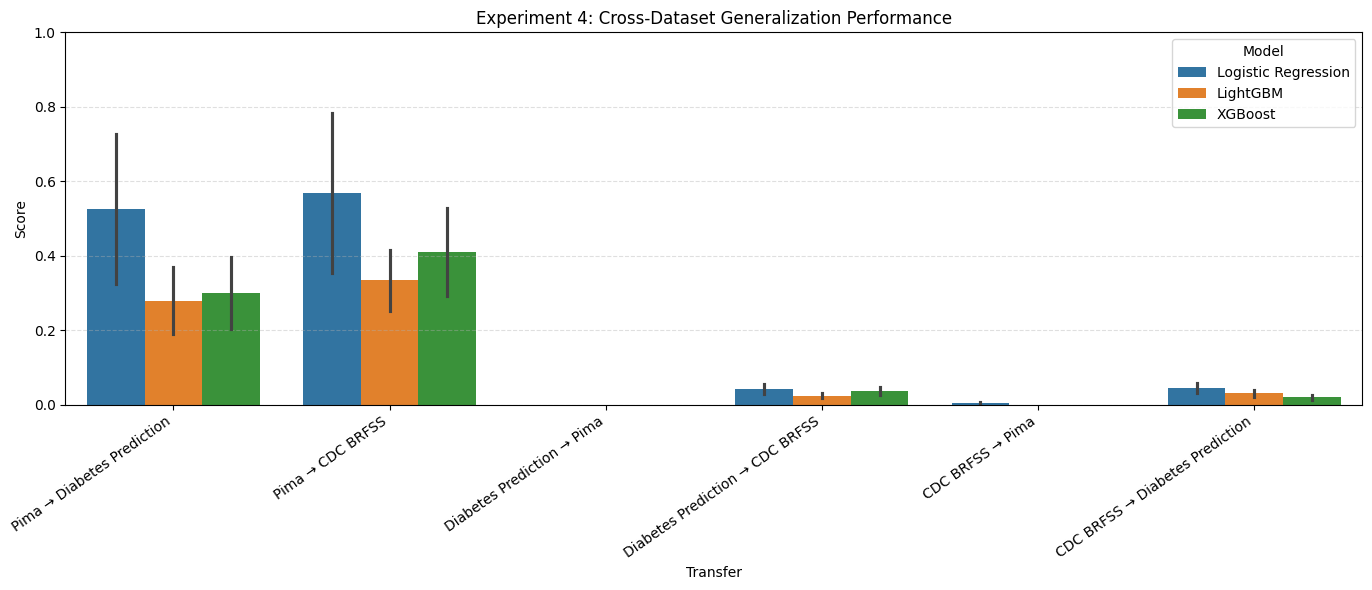

In [37]:
#34 Experiment 4: F1 and Recall Comparison Plot

plot_df = cross_results_df.copy()
plot_df["Transfer"] = plot_df["Train Dataset"] + " → " + plot_df["Test Dataset"]

melted_cross = plot_df.melt(
    id_vars=["Transfer", "Model"],
    value_vars=["F1 Score", "Recall"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(14, 6))
sns.barplot(data=melted_cross, x="Transfer", y="Score", hue="Model")
plt.title("Experiment 4: Cross-Dataset Generalization Performance")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Observation - Experiment 4 F1 and Recall Plot

The F1 and Recall plot shows that training on Pima transfers better than training on the larger population datasets. Pima-trained models are more likely to predict positive diabetes cases, which improves recall when tested on CDC BRFSS and Diabetes Prediction.

However, high recall does not necessarily mean strong overall performance. The low F1-scores show that the models are still making many incorrect predictions when transferred across datasets.

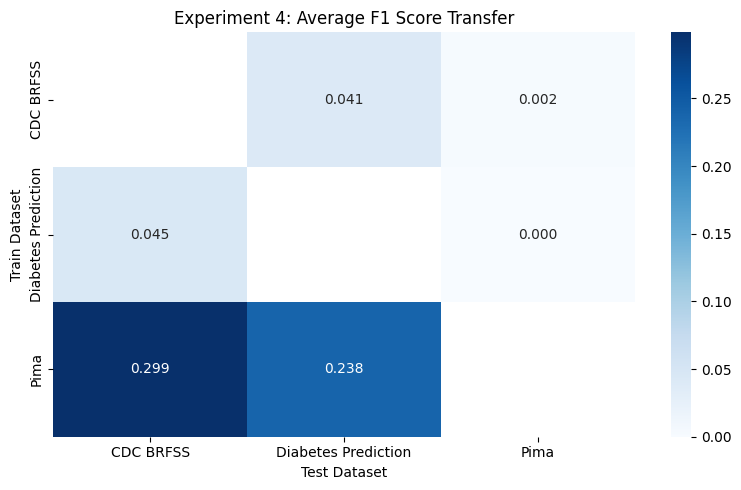

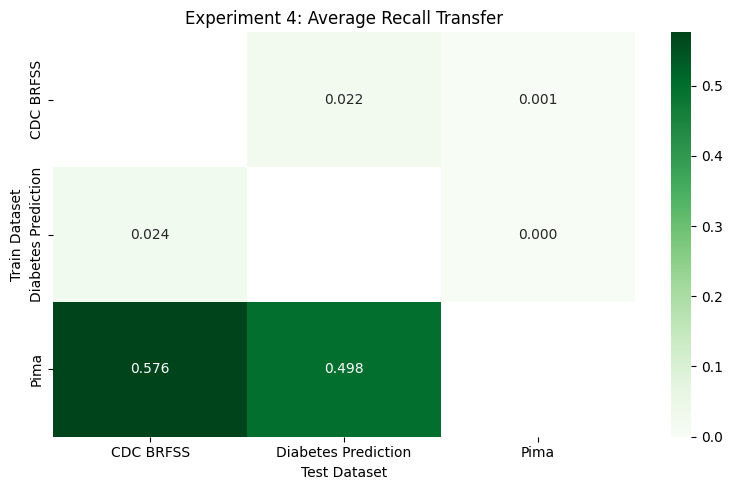

In [38]:
#35 Experiment 4: Average F1 and Recall heatmaps across models

avg_results = (
    cross_results_df
    .groupby(["Train Dataset", "Test Dataset"])[["F1 Score", "Recall"]]
    .mean()
    .reset_index()
)

f1_pivot = avg_results.pivot(
    index="Train Dataset",
    columns="Test Dataset",
    values="F1 Score"
)

recall_pivot = avg_results.pivot(
    index="Train Dataset",
    columns="Test Dataset",
    values="Recall"
)

plt.figure(figsize=(8, 5))
sns.heatmap(f1_pivot, annot=True, cmap="Blues", fmt=".3f")
plt.title("Experiment 4: Average F1 Score Transfer")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.heatmap(recall_pivot, annot=True, cmap="Greens", fmt=".3f")
plt.title("Experiment 4: Average Recall Transfer")
plt.tight_layout()
plt.show()

### Observation - Experiment 4 Heatmaps

The heatmaps show that cross-dataset transfer performance is uneven. The strongest average transfer occurs when training on Pima and testing on the other datasets, while the weakest transfers occur when testing on Pima.

This supports the idea of **feature drift** and population differences. Age and BMI alone do not capture enough information to make the models generalize reliably across all populations. Future cross-dataset work would need more shared clinical features or retraining on the target population.

In [39]:
#36 Save experiment 4 results

os.makedirs("results", exist_ok=True)

cross_results_df.to_csv(
    "results/cdc_experiment_4_cross_dataset_generalization.csv",
    index=False
)

cross_results_df.to_parquet(
    "results/cdc_experiment_4_cross_dataset_generalization.parquet",
    index=False
)

print("Experiment 4 results saved:")
print("- results/cdc_experiment_4_cross_dataset_generalization.csv")
print("- results/cdc_experiment_4_cross_dataset_generalization.parquet")

Experiment 4 results saved:
- results/cdc_experiment_4_cross_dataset_generalization.csv
- results/cdc_experiment_4_cross_dataset_generalization.parquet


In [40]:
#37 Experiment 4: Short Finding

best_transfer = cross_results_df.sort_values("F1 Score", ascending=False).iloc[0]
best_recall_transfer = cross_results_df.sort_values("Recall", ascending=False).iloc[0]

print("Experiment 4 Finding")
print("-" * 45)

print("Best transfer by F1 Score:")
print(
    f"{best_transfer['Train Dataset']} -> {best_transfer['Test Dataset']} "
    f"using {best_transfer['Model']} "
    f"(F1 = {best_transfer['F1 Score']:.4f})"
)

print("\nBest transfer by Recall:")
print(
    f"{best_recall_transfer['Train Dataset']} -> {best_recall_transfer['Test Dataset']} "
    f"using {best_recall_transfer['Model']} "
    f"(Recall = {best_recall_transfer['Recall']:.4f})"
)

print("\nInterpretation:")
print("Experiment 4 tests whether models trained on one population can generalize to another population.")
print("Only age and BMI were used because they are the common features across all three datasets.")
print("If performance drops across datasets, it suggests feature drift or population differences.")

Experiment 4 Finding
---------------------------------------------
Best transfer by F1 Score:
Pima -> CDC BRFSS using Logistic Regression (F1 = 0.3542)

Best transfer by Recall:
Pima -> CDC BRFSS using Logistic Regression (Recall = 0.7829)

Interpretation:
Experiment 4 tests whether models trained on one population can generalize to another population.
Only age and BMI were used because they are the common features across all three datasets.
If performance drops across datasets, it suggests feature drift or population differences.


In [41]:
exp4_best = cross_results_df.sort_values("F1 Score", ascending=False).iloc[0]

print(f"Experiment 4 best transfer by F1: {exp4_best['Train Dataset']} → {exp4_best['Test Dataset']} using {exp4_best['Model']} ({exp4_best['F1 Score']:.4f})")

Experiment 4 best transfer by F1: Pima → CDC BRFSS using Logistic Regression (0.3542)


In [42]:
#39 Final CDC Experiment Summary

print("Final CDC Experiment Summary")
print("-" * 45)

exp1_best = exp1_df.sort_values("F1 Score", ascending=False).iloc[0]
exp2_best_f1 = exp2_df.sort_values("F1 Score", ascending=False).iloc[0]
exp2_best_recall = exp2_df.sort_values("Recall", ascending=False).iloc[0]
exp3_best = exp3_df.sort_values("F1 Score", ascending=False).iloc[0]
exp4_best = cross_results_df.sort_values("F1 Score", ascending=False).iloc[0]
topk_best = topk_df[topk_df["Feature Set"] != "All Features"].sort_values("F1 Score", ascending=False).iloc[0]
exp4_best_recall = cross_results_df.sort_values("Recall", ascending=False).iloc[0]

print(f"Experiment 1 best baseline by F1: {exp1_best['Model']} ({exp1_best['F1 Score']:.4f})")

print(
    f"Experiment 2 best by F1: "
    f"{exp2_best_f1['Experiment']} - {exp2_best_f1['Model']} "
    f"({exp2_best_f1['F1 Score']:.4f})"
)

print(
    f"Experiment 2 best by Recall: "
    f"{exp2_best_recall['Experiment']} - {exp2_best_recall['Model']} "
    f"({exp2_best_recall['Recall']:.4f})"
)

print(
    f"Experiment 3 best tuned model by F1: "
    f"{exp3_best['Model']} ({exp3_best['F1 Score']:.4f})"
)

print(
    f"Experiment 3B best top-k result by F1: "
    f"{topk_best['Model']} using {topk_best['Feature Set']} "
    f"({topk_best['F1 Score']:.4f})"
)

print(
    f"Experiment 4 best transfer by F1: "
    f"{exp4_best['Train Dataset']} → {exp4_best['Test Dataset']} "
    f"using {exp4_best['Model']} ({exp4_best['F1 Score']:.4f})"
)

print(
    f"Experiment 4 best transfer by Recall: "
    f"{exp4_best_recall['Train Dataset']} → {exp4_best_recall['Test Dataset']} "
    f"using {exp4_best_recall['Model']} ({exp4_best_recall['Recall']:.4f})"
)

print("\nTop 5 CDC features from tuned tree models:")
for feature in importance_df.head(5)["Feature"].tolist():
    print(f"- {feature}")

print("\nOverall Interpretation:")
print("Experiment 1 gave the raw imbalanced baseline.")
print("Experiment 2 showed whether SMOTE or class weighting improved Recall/F1.")
print("Experiment 3 identified the most important CDC BRFSS predictors.")
print("Experiment 3B compared top-k features against all features.")
print("Experiment 4 tested cross-dataset generalization using shared Age and BMI features.")
print("CDC BRFSS does not contain HbA1c or Glucose, so CDC feature importance is based on survey health/lifestyle indicators.")

Final CDC Experiment Summary
---------------------------------------------
Experiment 1 best baseline by F1: LightGBM (0.2536)
Experiment 2 best by F1: SMOTE - Logistic Regression (0.4429)
Experiment 2 best by Recall: Class Weighting - LightGBM (0.7915)
Experiment 3 best tuned model by F1: Tuned XGBoost (0.3195)
Experiment 3B best top-k result by F1: Tuned XGBoost using Top 5 Features (0.4051)
Experiment 4 best transfer by F1: Pima → CDC BRFSS using Logistic Regression (0.3542)
Experiment 4 best transfer by Recall: Pima → CDC BRFSS using Logistic Regression (0.7829)

Top 5 CDC features from tuned tree models:
- GenHlth
- HighBP
- Age
- BMI
- Fruits

Overall Interpretation:
Experiment 1 gave the raw imbalanced baseline.
Experiment 2 showed whether SMOTE or class weighting improved Recall/F1.
Experiment 3 identified the most important CDC BRFSS predictors.
Experiment 3B compared top-k features against all features.
Experiment 4 tested cross-dataset generalization using shared Age and BMI